# Comparative Study of Four Neural Machine Translation Architectures


## Objective

The aim of this project is to compare four neural machine translation models on
the same dataset, under the same settings, and to explain why their results
differ:

1. **Recurrent Neural Network (RNN)** — a single RNN, no decoder
2. **Encoder–Decoder** — one fixed-length context vector
3. **Encoder–Decoder with Additive Attention** (Bahdanau et al., 2014)
4. **Encoder–Decoder with Multiplicative Attention** (Luong et al., 2015)

The dataset is the Japanese–English sentence pairs from the
[ManyThings.org Anki datasets](https://www.manythings.org/anki/).



# Theory

### 1. Recurrent Neural Network

A single RNN reads the source and emits a target token at every time step:

$$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b), \qquad \hat{y}_t = \mathrm{softmax}(W_{ho}h_t)$$

Nothing separates *reading* from *writing*. The prediction at step $t$ sees only
source tokens $1..t$ and never conditions on the target words already generated,
so the model cannot enforce agreement between them. It is a positional
transducer, not a translator — this is the baseline the other three are meant to
improve on.

### 2. Encoder–Decoder (Sequence-to-Sequence)

The encoder compresses the source into a final hidden state $c = h_T^{enc}$; a
separate decoder generates the target from it, conditioned at each step on the
previous target word:

$$s_t = f(s_{t-1}, y_{t-1}), \qquad s_0 = c, \qquad P(y_t \mid y_{<t}, x) = \mathrm{softmax}(W_o s_t)$$

Reading and writing are decoupled and the output length is free. The weakness is
the **information bottleneck**: everything the decoder learns about the source
must fit through one fixed-size vector.

### 3. Additive (Bahdanau) Attention

The decoder gets a *different* context vector at each step, a weighted average
over **all** encoder states:

$$e_{t,i} = v_a^\top \tanh(W_a s_t + U_a h_i), \qquad
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}, \qquad
c_t = \sum_i \alpha_{t,i} h_i$$

The alignment score comes from a small feed-forward network — hence *additive*.

### 4. Multiplicative (Luong dot) Attention

Luong replaces that network with a dot product, then merges context and decoder
state into an *attentional hidden state*:

$$e_{t,i} = s_t^\top h_i, \qquad
c_t = \sum_i \alpha_{t,i} h_i, \qquad
\tilde{s}_t = \tanh(W_c[c_t ; s_t])$$

The scorer itself has **no parameters**, which makes it cheaper, but it requires
the encoder and decoder states to live in a directly comparable space.

## Setup

In [1]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
import time
import math
import json
import os

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Using device = {torch.get_default_device()}")

Using device = cpu


### Reproducibility

The project brief requires `random_state = <roll number>`. Roll number
**ACE080BCT060** gives `RANDOM_STATE = 60`. `set_seed()` is called immediately
before **each** model is built, so all four architectures draw their initial
weights from the same random stream and receive mini-batches in the same order.
The architecture is then the only variable in the experiment.

In [2]:
RANDOM_STATE = 60

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

## Loading Data

In [3]:
SOS_token = 0 # Start of the Sentence
EOS_token = 1 # End of the Sentence
UNK_token = 2 # Token unseen during training

class Lang:
    def __init__(self, name, tokenizer=None):
        self.name = name
        # CHANGE FROM THE LABS: pluggable tokenizer (see "Tokenisation" below).
        # Passing nothing keeps the lab behaviour, sentence.split(' ').
        self.tokenize = tokenizer if tokenizer is not None else (lambda s: s.split(' '))
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "UNK"}
        self.n_words = 3  # Count SOS, EOS and UNK

    def addSentence(self, sentence):
        for word in self.tokenize(sentence):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

### Change from the labs (1 of 4): script-aware normalisation

The lab `normalizeString` folds accents to ASCII and then deletes everything
outside `[a-zA-Z!?]`. That is right for French (`é → e`), but applied to a
Japanese sentence it deletes **the whole sentence**:

```python
normalizeString("私は太っている")   # -> ''   (empty!)
```

So the English side keeps the lab function unchanged, and the Japanese side gets
its own: NFKC normalisation (which folds full-width Latin and digits onto their
half-width forms) followed by punctuation removal, leaving kana and kanji
untouched.

In [4]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters  [unchanged from the labs]
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

# CHANGE FROM THE LABS: a normaliser that does not destroy CJK text.
JP_PUNCT = set("。、！？「」『』・…‥〜ー－―（）(),.!?\"'　 ")

def normalizeJapanese(s):
    s = unicodedata.normalize('NFKC', s.strip())
    return ''.join(ch for ch in s if ch not in JP_PUNCT)

# Demonstration of why this is needed
demo = "私は太っている"
print("lab normalizeString :", repr(normalizeString(demo)))
print("normalizeJapanese   :", repr(normalizeJapanese(demo)))

lab normalizeString : ''
normalizeJapanese   : '私は太っている'


### Change from the labs (2 of 4): character tokenisation for Japanese

Japanese is written without spaces, so the lab's `sentence.split(' ')` returns
the entire sentence as a single token. The vocabulary would then be a list of
whole sentences and nothing would generalise.

The source side is therefore tokenised **per character** (kanji / kana). A
morphological analyser such as MeCab or Janome would give linguistically better
units, but character tokenisation needs no extra dependency and is a standard
baseline for Japanese at this scale. The English target stays word-level, exactly
as in the labs.

In [5]:
def word_tokenize(s):
    return [t for t in s.split(' ') if t]

def char_tokenize(s):
    return list(s)

print("word_tokenize('i am a translator') ->", word_tokenize('i am a translator'))
print("char_tokenize('私は翻訳家です')      ->", char_tokenize('私は翻訳家です'))

word_tokenize('i am a translator') -> ['i', 'am', 'a', 'translator']
char_tokenize('私は翻訳家です')      -> ['私', 'は', '翻', '訳', '家', 'で', 'す']


In [6]:
def readLangs(path:str):
    lang1 = 'eng'; lang2 = 'jpn'
    print("Reading lines...")

    # Read the file and split into lines
    lines = open(path, encoding='utf-8').\
        read().strip().split('\n')

    # ManyThings rows are: english <TAB> japanese <TAB> attribution.
    # Only the first two columns are used, and they are reversed so the source
    # is Japanese and the target English (same direction as the labs: the
    # non-English language is the input).
    pairs = []
    for l in lines:
        parts = l.split('\t')
        if len(parts) < 2:
            continue
        pairs.append([normalizeJapanese(parts[1]), normalizeString(parts[0])])

    # Input is Japanese (char-tokenised), output is English (word-tokenised)
    input_lang = Lang(lang2, char_tokenize)
    output_lang = Lang(lang1, word_tokenize)

    return input_lang, output_lang, pairs

### Change from the labs (3 of 4): separate source and target lengths

The labs use one `MAX_LENGTH = 5` for both sides, which works when both are
word-tokenised French and English of similar length. Here a Japanese sentence of
~8 *characters* maps to ~4 English *words*, so one shared limit cannot fit both.

* `MAX_SOURCE_LEN = 14` characters (including `EOS`)
* `MAX_TARGET_LEN = 6` words (including `EOS`)

Source rows are additionally padded to `PAD_SOURCE_LEN = max(14, 6) = 14` so the
plain-RNN baseline — which reads its output off source positions — always has
enough positions to emit a full target sentence.

The `eng_prefixes` filter is kept exactly as in the labs.

In [7]:
MAX_SOURCE_LEN = 14   # characters, incl. EOS
MAX_TARGET_LEN = 6    # words, incl. EOS
PAD_SOURCE_LEN = max(MAX_SOURCE_LEN, MAX_TARGET_LEN)

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(char_tokenize(p[0])) < MAX_SOURCE_LEN and \
        len(word_tokenize(p[1])) < MAX_TARGET_LEN and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

### Change from the labs (4 of 4): a held-out test set

The lab notebooks build the vocabulary over the whole corpus and then report BLEU
on sentences drawn from the same pairs the model trained on, which measures
memorisation rather than translation.

Here the pairs are split **80/20** with `random_state = 60` *before* anything is
fitted, and the vocabulary is counted on the **training split only** — so a test
token never seen in training becomes `UNK` instead of receiving its own
embedding. Every number reported below is on the held-out 20%.

In [8]:
def prepareData(path, verbose=True):
    input_lang, output_lang, pairs = readLangs(path)
    if verbose: print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    if verbose: print("Trimmed to %s sentence pairs" % len(pairs))

    # CHANGE FROM THE LABS: split before counting words, so the vocabulary
    # cannot leak information from the test set.
    train_pairs, test_pairs = train_test_split(
        pairs, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
    )

    if verbose: print("Counting words (training split only)...")
    for pair in train_pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    if verbose:
        print("Train pairs: %d | Test pairs: %d" % (len(train_pairs), len(test_pairs)))
        print("Counted tokens:")
        print(input_lang.name, input_lang.n_words)
        print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, train_pairs, test_pairs

In [9]:
PATH = 'data/jpn.txt'

set_seed()
input_lang, output_lang, train_pairs, test_pairs = prepareData(PATH)
print()
print(random.choice(train_pairs))

Reading lines...


Read 117022 sentence pairs
Trimmed to 2662 sentence pairs
Counting words (training split only)...
Train pairs: 2129 | Test pairs: 533
Counted tokens:
jpn 885
eng 1070

['今日は家にいます', 'i m staying home today']


In [10]:
for pair in random.sample(train_pairs, 8):
    print("%-18s (%2d chars)  ->  %s" % (pair[0], len(char_tokenize(pair[0])), pair[1]))

あの女は実にセクシだ         (10 chars)  ->  she s a fox
私たちは男です            ( 7 chars)  ->  we re boys
私たちは専業主婦です         (10 chars)  ->  we re housewives
彼は資産家だ             ( 6 chars)  ->  he s a wealthy man
彼女はお風呂にいます         (10 chars)  ->  she is in the bathroom
彼はキッチンにいる          ( 9 chars)  ->  he s in the kitchen
へとへとよ              ( 5 chars)  ->  i m exhausted
まだ罪悪感に苛まれている       (12 chars)  ->  i m still feeling guilty


## The four architectures

All four expose the interface the lab training loop already expects:

```python
encoder(input_tensor)                                   -> (encoder_outputs, encoder_hidden)
decoder(encoder_outputs, encoder_hidden, target_tensor) -> (decoder_outputs, hidden, attentions)
```

so a single `train_epoch` and a single `evaluate` serve every model. Models 2–4
share the same `EncoderRNN`; only the decoder changes.

### Model 1 — Recurrent Neural Network

Following the vanilla RNN of **Lab 6** (`nn.RNN` → linear head), split into an
encoder/head pair so it fits the same training loop as the other three.

The head ignores `target_tensor` completely: there is no teacher forcing and no
autoregression, because the prediction at each step is read straight off the
corresponding source position. The first `MAX_TARGET_LEN` positions are taken as
the translation.

In [11]:
class VanillaRNNEncoder(nn.Module):
    """Embedding + RNN over the source (Lab 6 vanilla RNN)."""
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(VanillaRNNEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True, nonlinearity="tanh")
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        # A single sentence passed at evaluation time is not padded and may be
        # shorter than the target; extend it so the head can emit a full sentence.
        deficit = MAX_TARGET_LEN - input.size(1)
        if deficit > 0:
            pad = torch.zeros(input.size(0), deficit, dtype=torch.long, device=input.device)
            input = torch.cat((input, pad), dim=1)

        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded)
        return output, hidden


class VanillaRNNHead(nn.Module):
    """Projects each source position onto the target vocabulary."""
    def __init__(self, hidden_size, output_size):
        super(VanillaRNNHead, self).__init__()
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        # target_tensor is ignored: no teacher forcing, no autoregression.
        logits = self.out(encoder_outputs[:, :MAX_TARGET_LEN, :])
        decoder_outputs = F.log_softmax(logits, dim=-1)
        return decoder_outputs, encoder_hidden, None

### Shared encoder for models 2–4

Unchanged from Lab 8 / Lab 9 / Lab 10.

In [12]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded)
        return output, hidden

### Model 2 — Encoder–Decoder

From **Lab 8**, unchanged except that the decode loop runs for `MAX_TARGET_LEN`
steps instead of `MAX_LENGTH`.

In [13]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_TARGET_LEN):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1) # values, index of the highest-scoring word
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.rnn(output, hidden)
        output = self.out(output)
        return output, hidden

### Model 3 — Additive (Bahdanau) attention

From **Lab 7**, unchanged.

In [14]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # e_{t,i} = v_a^T tanh(W_a s_t + U_a h_i)
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

### Model 4 — Multiplicative (Luong dot) attention

From **Lab 9 / Lab 10**, unchanged.

In [15]:
class LuongDotAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongDotAttention, self).__init__()

        # For:
        # s~_t = tanh(W_c[c_t;s_t])
        self.Wc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, query, keys):
        """
        query: current decoder hidden state s_t      (batch, 1, hidden)
        keys : encoder hidden states h_1..h_T        (batch, seq_len, hidden)
        """
        # Alignment scores: e_{t,i} = s_t^T h_i
        scores = torch.bmm(query, keys.transpose(1, 2))

        # Attention weights: alpha_{t,i} = softmax(e_{t,i})
        weights = F.softmax(scores, dim=-1)

        # Context vector: c_t = sum(alpha_{t,i} * h_i)
        context = torch.bmm(weights, keys)

        # Concatenate context and decoder hidden state: [c_t ; s_t]
        combined = torch.cat((context, query), dim=-1)

        # Attentional hidden state: s~_t = tanh(W_c[c_t;s_t])
        attentional_hidden = torch.tanh(self.Wc(combined))

        return attentional_hidden, weights

### The shared attention decoder

Identical to the labs, with the scorer passed in so models 3 and 4 differ in
**exactly one** component. The decode loop runs for `MAX_TARGET_LEN` steps.

In [16]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, attention, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = attention          # BahdanauAttention or LuongDotAttention
        self.rnn = nn.RNN(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_TARGET_LEN):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden.permute(1, 0, 2) # seq_len, batch, hidden -> batch, seq_len, hidden
        context, attn_weights = self.attention(query, encoder_outputs)
        input_rnn = torch.cat((embedded, context), dim=2)

        output, hidden = self.rnn(input_rnn, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

### One builder for all four

Keeps the four configurations in one place so the experiment loop cannot
accidentally differ between them.

In [17]:
MODEL_NAMES = {
    "rnn":            "Recurrent Neural Network",
    "encdec":         "Encoder-Decoder",
    "additive":       "Encoder-Decoder + Additive (Bahdanau) Attention",
    "multiplicative": "Encoder-Decoder + Multiplicative (Luong) Attention",
}
ORDER = ["rnn", "encdec", "additive", "multiplicative"]

def build_model(name, hidden_size):
    if name == "rnn":
        encoder = VanillaRNNEncoder(input_lang.n_words, hidden_size)
        decoder = VanillaRNNHead(hidden_size, output_lang.n_words)
    elif name == "encdec":
        encoder = EncoderRNN(input_lang.n_words, hidden_size)
        decoder = DecoderRNN(hidden_size, output_lang.n_words)
    elif name == "additive":
        encoder = EncoderRNN(input_lang.n_words, hidden_size)
        decoder = AttnDecoderRNN(hidden_size, output_lang.n_words,
                                 BahdanauAttention(hidden_size))
    elif name == "multiplicative":
        encoder = EncoderRNN(input_lang.n_words, hidden_size)
        decoder = AttnDecoderRNN(hidden_size, output_lang.n_words,
                                 LuongDotAttention(hidden_size))
    else:
        raise ValueError("unknown model %r" % name)
    return encoder.to(device), decoder.to(device)


def count_parameters(encoder, decoder):
    return (sum(p.numel() for p in encoder.parameters() if p.requires_grad) +
            sum(p.numel() for p in decoder.parameters() if p.requires_grad))

## Training

### Prepare training data

As in the labs, but source rows are padded to `PAD_SOURCE_LEN` and target rows to
`MAX_TARGET_LEN`, and an unseen token maps to `UNK` rather than raising a
`KeyError`.

In [18]:
def indexesFromSentence(lang, sentence):
    # CHANGE FROM THE LABS: .get(..., UNK_token) instead of [word], because the
    # vocabulary is now fitted on the training split and test tokens may be new.
    return [lang.word2index.get(token, UNK_token) for token in lang.tokenize(sentence)]

def tensorFromSentence(lang, sentence, max_len=None):
    max_len = max_len or PAD_SOURCE_LEN
    indexes = indexesFromSentence(lang, sentence)[:max_len - 1]
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1], MAX_TARGET_LEN)
    return (input_tensor, target_tensor)

def get_dataloader(pairs, batch_size, shuffle=True):
    n = len(pairs)
    input_ids = np.zeros((n, PAD_SOURCE_LEN), dtype=np.int64)
    target_ids = np.zeros((n, MAX_TARGET_LEN), dtype=np.int64)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)[:PAD_SOURCE_LEN - 1]
        tgt_ids = indexesFromSentence(output_lang, tgt)[:MAX_TARGET_LEN - 1]
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    data = TensorDataset(torch.LongTensor(input_ids).to(device),
                         torch.LongTensor(target_ids).to(device))

    sampler = RandomSampler(data) if shuffle else None
    return DataLoader(data, sampler=sampler, batch_size=batch_size)

### Training loop

Unchanged from the labs.

In [19]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor) # teacher forcing

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [20]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

`train` follows the labs, with one addition: the held-out loss is measured every
`eval_every` epochs so the generalisation gap can be discussed later. It returns
the loss history instead of plotting immediately, because four models are
compared on one figure.

In [21]:
@torch.no_grad()
def evaluate_loss(dataloader, encoder, decoder, criterion):
    encoder.eval(); decoder.eval()
    total = 0
    for input_tensor, target_tensor in dataloader:
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)
        total += criterion(decoder_outputs.view(-1, decoder_outputs.size(-1)),
                           target_tensor.view(-1)).item()
    encoder.train(); decoder.train()
    return total / len(dataloader)


def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
          print_every=25, test_dataloader=None, eval_every=10):
    start = time.time()
    plot_losses = []
    test_losses = []
    print_loss_total = 0

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder,
                           encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_losses.append(loss)

        if test_dataloader is not None and (epoch % eval_every == 0 or epoch == 1):
            test_losses.append((epoch, evaluate_loss(test_dataloader, encoder, decoder, criterion)))

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

    return {"train_loss": plot_losses, "test_loss": test_losses,
            "seconds": time.time() - start}

## Evaluation Code

`evaluate` and `evaluateRandomly` are the lab functions. `calculate_bleu` extends
Lab 10's to run over the **whole test set** rather than a random sample, and to
report BLEU-1 through BLEU-4 plus three diagnostics explained below.

In [22]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn


def evaluateRandomly(encoder, decoder, pairs, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

### Why BLEU alone is not enough here

Every English reference in this corpus is a **two-token template** (`i m`,
`he is`, `you re`, …) followed by one to three **content words**. The template is
largely determined by the source subject, so roughly half of any BLEU-1 score is
obtainable without understanding the sentence at all.

Three extra diagnostics separate the two:

* `prefix_accuracy` — got the two-token template right (nearly free)
* `content_accuracy` — got **all** the content words right
* `content_recall` — fraction of reference content tokens recovered

The gap between the first and the last two is what actually separates the
architectures.

In [23]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

smooth = SmoothingFunction().method1
PREFIX_LEN = 2   # every reference starts with a 2-token subject+copula template


def calculate_bleu(encoder, decoder, input_lang, output_lang, pairs, verbose=False):
    encoder.eval(); decoder.eval()

    weight_sets = {1: (1, 0, 0, 0), 2: (0.5, 0.5, 0, 0),
                   3: (1/3, 1/3, 1/3, 0), 4: (0.25, 0.25, 0.25, 0.25)}
    scores = {n: [] for n in weight_sets}
    references, hypotheses, records = [], [], []
    exact = prefix_hits = content_hits = 0
    recall_num = recall_den = 0

    for source, target in pairs:
        output_words, _ = evaluate(encoder, decoder, source, input_lang, output_lang)
        if "<EOS>" in output_words:
            output_words.remove("<EOS>")

        reference = target.split()
        candidate = output_words

        for n, w in weight_sets.items():
            scores[n].append(sentence_bleu([reference], candidate, weights=w,
                                           smoothing_function=smooth))

        ref_prefix, ref_content = reference[:PREFIX_LEN], reference[PREFIX_LEN:]
        cand_prefix, cand_content = candidate[:PREFIX_LEN], candidate[PREFIX_LEN:]

        if candidate == reference:      exact += 1
        if cand_prefix == ref_prefix:   prefix_hits += 1
        if cand_content == ref_content: content_hits += 1

        remaining = list(cand_content)
        for token in ref_content:
            if token in remaining:
                remaining.remove(token)
                recall_num += 1
        recall_den += len(ref_content)

        references.append([reference])
        hypotheses.append(candidate)
        records.append({"source": source, "reference": target,
                        "prediction": " ".join(candidate),
                        "bleu2": scores[2][-1]})

        if verbose:
            print("=" * 60)
            print("Japanese Input      :", source)
            print("Reference (English) :", target)
            print("Prediction (English):", " ".join(candidate))
            print("BLEU-1    :", round(scores[1][-1], 4))
            print("BLEU-2    :", round(scores[2][-1], 4))

    n_pairs = len(pairs)
    metrics = {"bleu%d" % n: sum(v) / len(v) for n, v in scores.items()}
    metrics["corpus_bleu4"] = corpus_bleu(references, hypotheses, smoothing_function=smooth)
    metrics["exact_match"] = exact / n_pairs
    metrics["prefix_accuracy"] = prefix_hits / n_pairs
    metrics["content_accuracy"] = content_hits / n_pairs
    metrics["content_recall"] = recall_num / recall_den if recall_den else 0.0
    return metrics, records

## Training and Evaluating

Every model is trained with exactly the same settings, so that the architecture
is the only thing that changes between the four runs.

| Setting | Value |
|---|---|
| Hidden size / embedding size | 128 |
| RNN | 1 layer, `nn.RNN` with tanh, dropout 0.1 |
| Optimiser | Adam, lr 0.001 (separate optimisers for encoder and decoder, as in the labs) |
| Batch size | 32 |
| Epochs | 200 |
| Loss | `NLLLoss`, with teacher forcing |
| Decoding | greedy (no beam search) |
| Seed | 60, re-applied before each model |

Calling `set_seed()` immediately before each model is built makes all four start
from the same random stream and receive the mini-batches in the same order, so
any difference in the results comes from the architecture.

In [24]:
hidden_size = 128
batch_size = 32
EPOCHS = 200

set_seed()
train_dataloader = get_dataloader(train_pairs, batch_size)
test_dataloader = get_dataloader(test_pairs, batch_size, shuffle=False)

print("train batches:", len(train_dataloader), "| test batches:", len(test_dataloader))

train batches: 67 | test batches: 17


In [25]:
results = {}     # key -> metrics
histories = {}   # key -> loss history
samples = {}     # key -> per-sentence records
models = {}      # key -> (encoder, decoder)

for key in ORDER:
    print("=" * 72)
    print("Training:", MODEL_NAMES[key])
    print("=" * 72)

    # Re-seed so every architecture sees the same initialisation stream
    # and the same batch order.
    set_seed()
    train_dataloader = get_dataloader(train_pairs, batch_size)

    encoder, decoder = build_model(key, hidden_size)
    history = train(train_dataloader, encoder, decoder, EPOCHS,
                    print_every=50, test_dataloader=test_dataloader)

    test_metrics, records = calculate_bleu(encoder, decoder, input_lang, output_lang, test_pairs)
    train_metrics, _ = calculate_bleu(encoder, decoder, input_lang, output_lang,
                                      train_pairs[:len(test_pairs)])

    test_metrics["parameters"] = count_parameters(encoder, decoder)
    test_metrics["train_bleu2"] = train_metrics["bleu2"]
    results[key] = test_metrics
    histories[key] = history
    samples[key] = records
    models[key] = (encoder, decoder)

    print()
    print("Test BLEU-1 %.4f | BLEU-2 %.4f | BLEU-4 %.4f | exact %.4f | params %d"
          % (test_metrics["bleu1"], test_metrics["bleu2"], test_metrics["bleu4"],
             test_metrics["exact_match"], test_metrics["parameters"]))
    print("     prefix %.4f | content %.4f | content recall %.4f"
          % (test_metrics["prefix_accuracy"], test_metrics["content_accuracy"],
             test_metrics["content_recall"]))
    print()

Training: Recurrent Neural Network


0m 12s (- 0m 37s) (50 25%) 1.4246


0m 24s (- 0m 24s) (100 50%) 0.5835


0m 35s (- 0m 11s) (150 75%) 0.5215


0m 46s (- 0m 0s) (200 100%) 0.5051


...

1m 11s (- 3m 33s) (50 25%) 1.2062


2m 22s (- 2m 22s) (100 50%) 0.3761


3m 35s (- 1m 11s) (150 75%) 0.2444


4m 46s (- 0m 0s) (200 100%) 0.1928



Test BLEU-1 0.3946 | BLEU-2 0.3037 | BLEU-4 0.1669 | exact 0.0432 | params 503598
     prefix 0.4916 | content 0.1032 | content recall 0.2584



## Results

In [26]:
def show_table(rows, headers):
    widths = [max(len(str(r[i])) for r in [headers] + rows) for i in range(len(headers))]
    line = " | ".join(h.ljust(w) for h, w in zip(headers, widths))
    print(line)
    print("-" * len(line))
    for r in rows:
        print(" | ".join(str(c).ljust(w) for c, w in zip(r, widths)))


rows = [[MODEL_NAMES[k].replace("Encoder-Decoder + ", "+ ").replace(" Attention", ""),
         results[k]["parameters"],
         "%.4f" % results[k]["bleu1"], "%.4f" % results[k]["bleu2"],
         "%.4f" % results[k]["bleu4"], "%.4f" % results[k]["corpus_bleu4"],
         "%.4f" % results[k]["exact_match"]] for k in ORDER]
show_table(rows, ["Architecture", "Params", "BLEU-1", "BLEU-2", "BLEU-4", "Corpus-4", "Exact"])

Architecture             | Params | BLEU-1 | BLEU-2 | BLEU-4 | Corpus-4 | Exact 
--------------------------------------------------------------------------------
Recurrent Neural Network | 284334 | 0.4651 | 0.3484 | 0.1916 | 0.1853   | 0.0450
Encoder-Decoder          | 454318 | 0.0829 | 0.0563 | 0.0258 | 0.0058   | 0.0000
+ Additive (Bahdanau)    | 503855 | 0.5408 | 0.4246 | 0.2415 | 0.2519   | 0.0882
+ Multiplicative (Luong) | 503598 | 0.3946 | 0.3037 | 0.1669 | 0.1639   | 0.0432


### Where the score comes from: template vs content

This is the table that explains the ranking. Compare `Prefix` (nearly free)
against `Content` (requires actually reading the source).

In [27]:
rows = [[MODEL_NAMES[k].replace("Encoder-Decoder + ", "+ ").replace(" Attention", ""),
         "%.4f" % results[k]["prefix_accuracy"],
         "%.4f" % results[k]["content_accuracy"],
         "%.4f" % results[k]["content_recall"],
         "%.4f" % results[k]["exact_match"]] for k in ORDER]
show_table(rows, ["Architecture", "Prefix", "Content", "ContentRecall", "Exact"])

Architecture             | Prefix | Content | ContentRecall | Exact 
--------------------------------------------------------------------
Recurrent Neural Network | 0.5591 | 0.0919  | 0.3136        | 0.0450
Encoder-Decoder          | 0.1351 | 0.0000  | 0.0222        | 0.0000
+ Additive (Bahdanau)    | 0.6510 | 0.1745  | 0.3942        | 0.0882
+ Multiplicative (Luong) | 0.4916 | 0.1032  | 0.2584        | 0.0432


### BLEU-2 by source length

The direct test of the bottleneck hypothesis.

In [28]:
def length_bucket(n):
    lo = ((n - 1) // 3) * 3 + 1
    return "%d-%d" % (lo, lo + 2)

buckets_all = {}
for key in ORDER:
    buckets = {}
    for rec in samples[key]:
        b = length_bucket(len(char_tokenize(rec["source"])))
        buckets.setdefault(b, []).append(rec["bleu2"])
    buckets_all[key] = {b: sum(v) / len(v) for b, v in buckets.items()}

labels = sorted({b for d in buckets_all.values() for b in d}, key=lambda x: int(x.split("-")[0]))
rows = [[MODEL_NAMES[k].replace("Encoder-Decoder + ", "+ ").replace(" Attention", "")] +
        ["%.4f" % buckets_all[k][b] if b in buckets_all[k] else "-" for b in labels]
        for k in ORDER]
show_table(rows, ["Architecture"] + [b + " ch" for b in labels])

Architecture             | 1-3 ch | 4-6 ch | 7-9 ch | 10-12 ch | 13-15 ch
-------------------------------------------------------------------------
Recurrent Neural Network | 0.5897 | 0.3916 | 0.3702 | 0.2985   | 0.2163  
Encoder-Decoder          | 0.1447 | 0.1085 | 0.0102 | 0.0638   | 0.1807  
+ Additive (Bahdanau)    | 0.4853 | 0.4216 | 0.4417 | 0.4102   | 0.3579  
+ Multiplicative (Luong) | 0.3925 | 0.2980 | 0.3288 | 0.2730   | 0.2728  


### Training curves

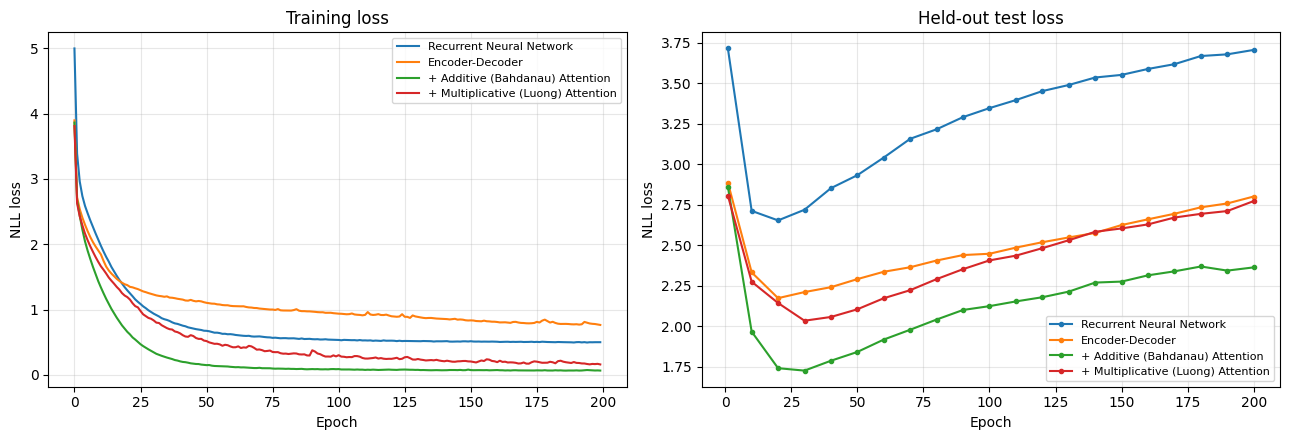

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for key in ORDER:
    axes[0].plot(histories[key]["train_loss"], label=MODEL_NAMES[key].replace("Encoder-Decoder + ", "+ "))
    pts = histories[key]["test_loss"]
    axes[1].plot([p[0] for p in pts], [p[1] for p in pts], marker="o", markersize=3,
                 label=MODEL_NAMES[key].replace("Encoder-Decoder + ", "+ "))

axes[0].set_title("Training loss"); axes[1].set_title("Held-out test loss")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("NLL loss"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

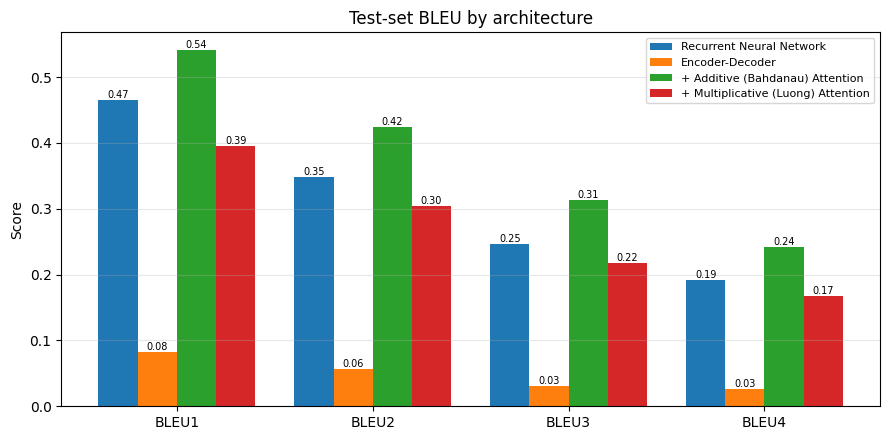

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics_to_plot = ["bleu1", "bleu2", "bleu3", "bleu4"]
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, key in enumerate(ORDER):
    vals = [results[key][m] for m in metrics_to_plot]
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=MODEL_NAMES[key].replace("Encoder-Decoder + ", "+ "))
    ax.bar_label(bars, fmt="%.2f", fontsize=7)

ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Score"); ax.set_title("Test-set BLEU by architecture")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Attention heat maps

What each attention mechanism is actually looking at.

using CJK font: Yu Gothic


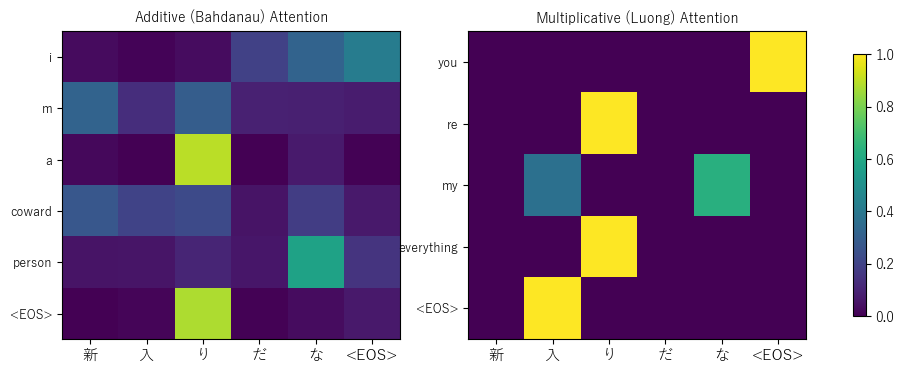

source: 新入りだな | reference: you re new huh ?


In [31]:
def plot_attention(encoder, decoder, sentence, title, ax):
    output_words, attentions = evaluate(encoder, decoder, sentence, input_lang, output_lang)
    weights = attentions[0].cpu().numpy()
    src_tokens = char_tokenize(sentence) + ['<EOS>']
    tgt_tokens = output_words
    weights = weights[:len(tgt_tokens), :len(src_tokens)]

    im = ax.imshow(weights, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens))); ax.set_xticklabels(src_tokens, fontsize=11)
    ax.set_yticks(range(len(tgt_tokens))); ax.set_yticklabels(tgt_tokens, fontsize=9)
    ax.set_title(title, fontsize=10)
    return im

# a font that can render kana/kanji, else the labels come out as empty boxes
from matplotlib import font_manager
available = {f.name for f in font_manager.fontManager.ttflist}
for name in ("Yu Gothic", "MS Gothic", "Meiryo", "Noto Sans CJK JP", "Noto Sans JP"):
    if name in available:
        plt.rcParams["font.family"] = [name]
        print("using CJK font:", name)
        break

sentence = test_pairs[0][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ["additive", "multiplicative"]):
    enc, dec = models[key]
    im = plot_attention(enc, dec, sentence, MODEL_NAMES[key].replace("Encoder-Decoder + ", ""), ax)
fig.colorbar(im, ax=axes, shrink=0.85)
plt.show()
print("source:", sentence, "| reference:", test_pairs[0][1])

### Qualitative comparison

The lab's `evaluateRandomly`, run on **held-out** sentences, with all four models
side by side on the same inputs.

In [32]:
for i in range(8):
    rec = samples["rnn"][i]
    print("Japanese :", rec["source"])
    print("Reference:", rec["reference"])
    for key in ORDER:
        print("   %-16s %s" % (key + ":", samples[key][i]["prediction"]))
    print()

Japanese : 新入りだな
Reference: you re new huh ?
   rnn:             i m eating an
   encdec:          i m still not ready
   additive:        i m a coward person
   multiplicative:  you re my everything

Japanese : 私は翻訳家です
Reference: i am a translator
   rnn:             i m a
   encdec:          she s an appalling cook
   additive:        i m from school
   multiplicative:  i m a police officer

Japanese : 本当に楽しみです
Reference: i m really excited
   rnn:             i m really sorry
   encdec:          she s amiable to everybody
   additive:        i m really angry with
   multiplicative:  i m all ears

Japanese : 彼女はお手洗いにいます
Reference: she s in the restroom
   rnn:             he is a the SOS SOS
   encdec:          good teachers
   additive:        she s a big teaser
   multiplicative:  she is in the bath

Japanese : 彼らは付き合っている
Reference: they re going out together
   rnn:             he are a
   encdec:          i m very hungry
   additive:        they are in class
   multiplicative:  t

### A worked example, in the Lab 10 print format

In [33]:
enc, dec = models["additive"]
_ = calculate_bleu(enc, dec, input_lang, output_lang, test_pairs[:5], verbose=True)

Japanese Input      : 新入りだな
Reference (English) : you re new huh ?
Prediction (English): i m a coward person
BLEU-1    : 0
BLEU-2    : 0
Japanese Input      : 私は翻訳家です
Reference (English) : i am a translator
Prediction (English): i m from school
BLEU-1    : 0.25
BLEU-2    : 0.0913
Japanese Input      : 本当に楽しみです
Reference (English) : i m really excited
Prediction (English): i m really angry with
BLEU-1    : 0.6
BLEU-2    : 0.5477
Japanese Input      : 彼女はお手洗いにいます
Reference (English) : she s in the restroom
Prediction (English): she s a big teaser
BLEU-1    : 0.4
BLEU-2    : 0.3162
Japanese Input      : 彼らは付き合っている
Reference (English) : they re going out together
Prediction (English): they are in class
BLEU-1    : 0.1947
BLEU-2    : 0.0711


### Save the results

In [34]:
os.makedirs('results', exist_ok=True)

with open('results/metrics.json', 'w', encoding='utf-8') as f:
    json.dump({"random_state": RANDOM_STATE, "epochs": EPOCHS,
               "hidden_size": hidden_size, "batch_size": batch_size,
               "n_train": len(train_pairs), "n_test": len(test_pairs),
               "input_vocab": input_lang.n_words, "output_vocab": output_lang.n_words,
               "models": results}, f, indent=2)

with open('results/sample_translations.json', 'w', encoding='utf-8') as f:
    json.dump(samples, f, indent=2, ensure_ascii=False)

print("written to results/")

written to results/
